In [1]:
import xarray as xr
import numpy as np
from cftime import DatetimeProlepticGregorian
from datetime import timedelta

import pyvista as pv
import geovista as gv
from tqdm.auto import tqdm
import numpy as np

In [2]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})

    key = list(ds.variables.keys())[0]
    da = ds[key]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    elif set(ls) - {"zos"} == set(["thetao"]):
        variables = ["thetao"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    if "zos" in ls:
        variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})
    ds_out.attrs = ds.attrs

    return ds_out

In [3]:
dataset_name = "CM4"  # "OM4", "CM4"
# Long OM4 Rollout
# pred_path = '/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr'
# long_roll = True

# Short OM4 Rollout
# pred_path = "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-20_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975NofastinoutEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr"
# long_roll = False

# Short CM4 Rollout
pred_path = "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-11-22_ConvNextUNetCM4Hist1NofastinoutEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_13800_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_13800_rand_seed_1.zarr"
long_roll = False

levels = 19

In [4]:
import os


def get_om4_gt(long_roll):
    ds_input = xr.open_zarr(
        os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
    )
    if long_roll:
        time = 7300
        repeats = 40
        start_year = 1990
        years = 400

        ds_groundtruth = ds_groundtruth.sel(time=slice("1990-01-01", "1999-12-31"))
        ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
        dates = np.array(range(3, 365 * years, 5))
        base = DatetimeProlepticGregorian(start_year, 1, 1)
        all_dates = [base + timedelta(days=int(day - 1)) for day in dates]
        ds_groundtruth = ds_groundtruth.assign_coords(
            time=all_dates[: ds_groundtruth.time.size]
        )
        ds_groundtruth = ds_groundtruth.isel(time=slice(0, time))
    else:
        ds_input = ds_input.sel(time=slice("1975-01-01", None))
        ds_groundtruth = ds_input.isel(time=slice(2903, 2903 + 600)).isel(
            lev=slice(None, levels)
        )
    return ds_groundtruth


def get_cm4_gt():
    import fsspec

    fs_osn = fsspec.filesystem(
        "s3",
        profile="ocean_emulator",  ## This is the profile name you configured above.
    )
    mapper = fs_osn.get_mapper(
        "emulators/jbusecke/ocean-emulators/CM4_5daily_v0.4.0.zarr"
    )
    ds_input = xr.open_zarr(mapper, consolidated=True)
    ds_input = ds_input.drop_vars(["lat_b", "lon_b"])

    ds_groundtruth = ds_input.isel(time=slice(13941, 13941 + 600)).isel(
        lev=slice(None, levels)
    )
    return ds_groundtruth

In [5]:
if dataset_name == "OM4":
    ds_groundtruth = get_om4_gt(long_roll)
elif dataset_name == "CM4":
    ds_groundtruth = get_cm4_gt()
else:
    raise ValueError("Incorrect dataset name")

# ds_groundtruth = ds_groundtruth.astype("float32")

ds = xr.open_dataset(pred_path, engine="zarr", chunks={})
if long_roll:
    ds = ds.isel(time=slice(0, time))

ds = post_processor(ds, ds_groundtruth, ["thetao", "so", "zos"])  # Change in the future

### ENSO

In [6]:
data = ds_groundtruth  # .sel(time=slice("1990-01-01", "1999-12-31"))
ds_prediction = ds

In [7]:
clim = data["thetao"].sel(lev=slice(0, 500)).groupby("time.dayofyear").mean().compute()
data_surface = data.sel(lev=slice(0, 500))
ds_prediction_surface = ds_prediction.sel(lev=slice(0, 500))
clim_pred = ds_prediction_surface["thetao"].groupby("time.dayofyear").mean().compute()

In [8]:
def NinoIndexComputeClim(T, area, dt=5, window=150):
    T = T.load()
    T_clim = T.copy()
    T_clim = T_clim.sel(x=slice(118, 260), y=slice(-5, 5))
    area = area.sel(x=slice(118, 260), y=slice(-5, 5)).load()
    clim = T_clim.groupby("time.dayofyear").mean("time").compute()
    window = int(window / dt)
    for i, t in enumerate(T_clim.time.values):
        day = int(t.dayofyr)
        T_clim[i] = (T[i] - clim.sel(dayofyear=day)).data

    T_clim = T_clim.rolling(time=window).mean()
    # T_clim = T_clim.weighted(area).mean(["x", "y"])
    T_clim = T_clim.weighted(area).mean(["y"])

    return T_clim[window:]

In [9]:
nino_true_compute_clim = NinoIndexComputeClim(data_surface["thetao"], data["areacello"])
nino_true_compute_clim = nino_true_compute_clim.rename("Anomaly")
nino_true_compute_clim = nino_true_compute_clim.assign_attrs(units=r"$\degree C$")
nino_true_compute_clim["x"] = nino_true_compute_clim["x"].assign_attrs(
    units=r"${^o}$", long_name="longitude"
)
nino_true_compute_clim["lev"] = nino_true_compute_clim["lev"].assign_attrs(
    units=r"$m$", long_name="depth"
)

nino_pred_compute_clim = NinoIndexComputeClim(
    ds_prediction_surface["thetao"], ds_prediction_surface["areacello"]
)
nino_pred_compute_clim = nino_pred_compute_clim.rename("Anomaly")
nino_pred_compute_clim = nino_pred_compute_clim.assign_attrs(units=r"$\degree C$")
nino_pred_compute_clim["x"] = nino_pred_compute_clim["x"].assign_attrs(
    units=r"${^o}$", long_name="longitude"
)
nino_pred_compute_clim["lev"] = nino_pred_compute_clim["lev"].assign_attrs(
    units=r"$m$", long_name="depth"
)

In [10]:
nino_pred_compute_clim

<xarray.DataArray 'Anomaly' (time: 570, x: 142, lev: 9)> Size: 6MB
array([[[-0.05805443, -0.04341718, -0.07045677, ...,  0.14350334,
          0.06004476,  0.05785023],
        [-0.09440165, -0.07682536, -0.06929087, ...,  0.15462559,
          0.09749564,  0.07765901],
        [-0.08172479, -0.07449514, -0.06427936, ...,  0.20448721,
          0.10914644,  0.08029096],
        ...,
        [-0.27919348, -0.32410853, -0.39485077, ..., -0.10470036,
         -0.12658632, -0.05523761],
        [-0.27089569, -0.30483496, -0.37592842, ..., -0.10846168,
         -0.125665  , -0.05430661],
        [-0.25864222, -0.28019165, -0.34977813, ..., -0.11494491,
         -0.12604111, -0.05477796]],

       [[-0.05217551, -0.04030679, -0.06312659, ...,  0.14616288,
          0.06417016,  0.06125275],
        [-0.0853936 , -0.06955689, -0.06487289, ...,  0.15626339,
          0.10323804,  0.0830638 ],
        [-0.06848485, -0.06251456, -0.05583354, ...,  0.2069846 ,
          0.11848196,  0.08623268],
...
        [-0.78570445, -1.46975619, -2.31667718, ..., -0.24765861,
         -0.2154436 , -0.20737312],
        [-0.7285186 , -1.46777236, -2.35096116, ..., -0.2702304 ,
         -0.23500975, -0.22097473],
        [-0.67611403, -1.46063964, -2.37186763, ..., -0.29564268,
         -0.25336083, -0.23254443]],

       [[ 0.16432222,  0.26200927,  0.36550291, ...,  1.74402203,
          0.62000247,  0.21036508],
        [ 0.17053547,  0.26446893,  0.34292234, ...,  1.63503873,
          0.61575405,  0.21150121],
        [ 0.11762527,  0.25098594,  0.25932324, ...,  1.44844294,
          0.6353825 ,  0.23958484],
        ...,
        [-0.79333228, -1.47887298, -2.33204665, ..., -0.24808639,
         -0.21892071, -0.20708042],
        [-0.73483828, -1.47603463, -2.36751721, ..., -0.27134089,
         -0.23835386, -0.21988168],
        [-0.68219739, -1.4690359 , -2.39091431, ..., -0.29761931,
         -0.25677291, -0.23070841]]], shape=(570, 142, 9))
Coordinates:
    dz       (lev) int64 72B 5 10 15 20 30 50 70 100 150
  * time     (time) object 5kB 0342-05-26 00:00:00 ... 0350-03-12 00:00:00
  * x        (x) float64 1kB 118.5 119.5 120.5 121.5 ... 256.5 257.5 258.5 259.5
  * lev      (lev) float64 72B 2.5 10.0 22.5 40.0 65.0 105.0 165.0 250.0 375.0
Attributes:
    units:    $\degree C$

/pscratch/sd/s/suryad/conda_envs/pyvista/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(
ERROR:root:1: #version 140
2025-01-13 12:58:41.910 ( 101.373s) [    7FB86843F740]   vtkShaderProgram.cxx:468    ERR| vtkShaderProgram (0x5637aae1e700): 1: #version 140
2: #ifdef GL_ES
3: #ifdef GL_FRAGMENT_PRECISION_HIGH
4: precision highp float;
5: #else
6: precision mediump float;
7: #endif
8: #else // GL_ES
9: #define highp
10: #define mediump
11: #define lowp
12: #endif // GL_ES
13: 
14: 
15: // SPDX-FileCopyrightText: Copyright (c) Ken Martin, Will Schroeder, Bill Lorensen
16: // SPDX-License-Identifier: BSD-3-Clause
17: // Template for the polydata mappers geometry shader
18: 
19: uniform int PrimitiveIDOffset;
20: 
21: // VC position of this fragment
22: in vec4 vertexVCVSOutput[];
23: out vec4 vertexVCGSOutput;
24: 
25: // primitiveID
26: //VTK::PrimID::Dec


Grid points shape: (1278, 3)
Grid scalars shape: (1278,)


{
81:     vec2 tmp = normalize(pos[i+1] - pos[i]);
82:     tmp = ccw*vec2(-tmp.y, tmp.x);
83:     float d = dot(pos[i], tmp);
84:     edgeEqn[i] = vec4(tmp.x, tmp.y, 0.0, -d);
85:   }
86: 
87:   float edgeValues = 255.0*texelFetch(edgeTexture, gl_PrimitiveIDIn + PrimitiveIDOffset).r;
88: if (edgeValues < 4.0) edgeEqn[2].z = lineWidth;
89: if (mod(edgeValues, 4.0) < 2.0) edgeEqn[1].z = lineWidth;
90: if (mod(edgeValues, 2.0) < 1.0) edgeEqn[0].z = lineWidth;
91: 
92: 
93:   for (int i = 0; i < 3; i++)
94:     {
95:     gl_PrimitiveID = gl_PrimitiveIDIn;
96: 
97:     //VTK::Clip::Impl
98: 
99:     //VTK::Color::Impl
100: 
101:     //VTK::Normal::Impl
102: 
103:     //VTK::Light::Impl
104: 
105:     colorTCoordVCGSOutput = colorTCoordVCVSOutput[i];
106: 
107: 
108:     //VTK::DepthPeeling::Impl
109: 
110:     //VTK::Picking::Impl
111: 
112:     // VC position of this fragment
113:     vertexVCGSOutput = vertexVCVSOutput[i];
114: 
115:     // gl_Position = gl_in[i].gl_Position;
116: 
117:  

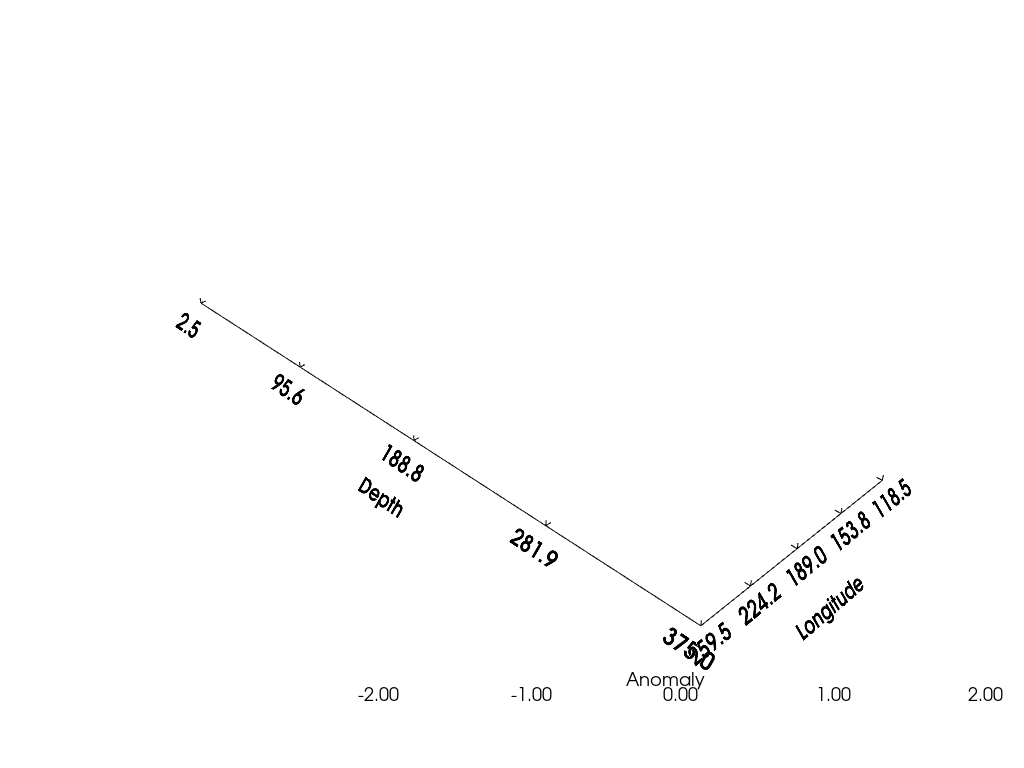

In [15]:
import pyvista as pv

ds = nino_true_compute_clim
# ds = nino_pred_compute_clim

# Coordinates (x and y)
x_vals = ds["x"].values
y_vals = ds["lev"].values
x, y = np.meshgrid(x_vals, y_vals)

# y = -y
# Initialize the grid with flat Z=0
z = np.zeros_like(x)

grid = pv.StructuredGrid(x, y, z)

# Add the initial anomaly data as scalars
initial_da = ds.isel(time=0)  # Extract first timestep
data_2d = initial_da.transpose("lev", "x").values  # Align lev and x dimensions
grid["Anomaly"] = data_2d.ravel()  # Flatten and assign

# Debug: Verify the grid points and scalars
print("Grid points shape:", grid.points.shape)
print("Grid scalars shape:", grid["Anomaly"].shape)

# Visualize to verify alignment
plotter = pv.Plotter()
plotter.add_mesh(
    grid,
    scalars="Anomaly",
    cmap="balance",
    show_edges=True,
    scalar_bar_args={"title": "Anomaly"},
    clim=(-2, 2),
)
plotter.show_bounds(xtitle="Longitude", ytitle="Depth")
plotter.show()

# Open a movie file
# plotter.open_movie("nino_animation_flat.mp4", framerate=10)

# # Loop over timesteps to update scalars and record frames
# n_times = ds.sizes['time']
# for t_i in range(n_times):
#     da = ds.isel(time=t_i)
#     grid["Anomaly"] = da.transpose('lev', 'x').values.ravel()  # Update scalars

#     # Optional: Add timestamp as text
#     plotter.add_text(
#         f"Time: {str(ds.isel(time=t_i).time.values)[:10]}",
#         position="upper_right",
#         font_size=10,
#         color="black",
#         name="time_text",
#     )

#     # Render and write the frame
#     plotter.render()
#     plotter.write_frame()
#     plotter.remove_actor("time_text")  # Remove timestamp text for the next frame

# plotter.close()

In [16]:
# Load and select a variable/time range. Assuming ds is your dataset:
# ds = nino_true_compute_clim.sel(time=slice("1990-01-01", "1999-12-31"))
# ds = nino_pred_compute_clim.sel(time=slice("1990-01-01", "1999-01-01"))
# ds = nino_true_compute_clim.isel(time=slice(0, 20))
ds = nino_pred_compute_clim.isel(time=slice(0, 20))
name = "cm4_pred_nino_animation"

mode = "cube"  # 'accurate' or 'cube'
rotate = True

# Coordinates
y_vals = ds["y"].values
x_vals = ds["x"].values
lev_vals = ds["lev"].values

NY = len(y_vals)
NX = len(x_vals)
NZ = len(lev_vals)

# Create coordinates for the grid
X_2d, Y_2d = np.meshgrid(x_vals, y_vals)
X_2d = X_2d.T  # (NX, NY)
Y_2d = Y_2d.T  # (NX, NY)

X_3d = np.broadcast_to(X_2d[..., np.newaxis], (NX, NY, NZ))
Y_3d = np.broadcast_to(Y_2d[..., np.newaxis], (NX, NY, NZ))
Z_3d = np.broadcast_to(lev_vals[np.newaxis, np.newaxis, :], (NX, NY, NZ))
Z_3d = -Z_3d


def normalize(coord):
    return (coord - coord.mean()) / (coord.max() - coord.min())


if mode == "cube":
    X_3d = normalize(X_3d)
    Y_3d = normalize(Y_3d)
    Z_3d = normalize(Z_3d)

grid = pv.StructuredGrid(X_3d, Y_3d, Z_3d)
grid.dimensions = (NX, NY, NZ)

# Extract the first timestep data to initialize the mesh
da = ds.isel(time=0)  # shape (y, x, lev)
data = da.values
data_3d = np.transpose(data, (1, 0, 2))  # (NX, NY, NZ)

# Add the initial scalars to the grid
grid["Anomaly"] = data_3d.ravel()

# Set up the Plotter and add the mesh with initial scalars explicitly
plotter = pv.Plotter()
mesh_actor = plotter.add_mesh(
    grid,
    scalars=grid["Anomaly"],
    cmap="balance",
    show_edges=False,
    clim=(-2, 2),
    scalar_bar_args={"title": "Anomaly"},
)

# Replace show_grid with show_bounds, specifying axis labels
plotter.show_bounds(
    xtitle="Longitude",
    ytitle="Latitude",
    ztitle="Depth",
    font_size=10,  # Adjust label size to make them smaller
)

plotter.reset_camera()
if mode == "accurate":
    plotter.view_xz()

else:
    plotter.view_isometric()

# plotter.camera.elevation += 30
# plotter.camera.azimuth += 10


# Open a movie file
plotter.open_movie(name + ".mp4", framerate=10)

n_times = ds.sizes["time"]
time_text = None
for t_i in range(n_times):
    da = ds.isel(time=t_i)
    data = da.values
    data_3d = np.transpose(data, (1, 0, 2))

    # Update scalars
    grid["Anomaly"] = data_3d.ravel()

    # Remove the old mesh actor
    plotter.remove_actor(mesh_actor)

    # Add the updated mesh again
    mesh_actor = plotter.add_mesh(
        grid,
        scalars="Anomaly",
        clim=(-2, 2),
        cmap="balance",
        show_edges=False,
        scalar_bar_args={"title": "Anomaly"},
    )

    if time_text:
        plotter.remove_actor("time_text")
    time_text = plotter.add_text(
        f"{str(ds.isel(time=t_i).time.values)[:10]}",
        position="upper_right",
        font_size=10,
        color="black",
        name="time_text",
    )
    if rotate:
        plotter.camera.azimuth += 1

    plotter.render()
    plotter.show_bounds(
        xtitle="Longitude",
        ytitle="Latitude",
        ztitle="Depth",
        font_size=10,  # Adjust label size to make them smaller
    )
    plotter.write_frame()

plotter.close()

### Rotating globe

In [72]:
import pyvista as pv
import geovista as gv
from tqdm.auto import tqdm


def make_points(r, n, xoffset, yoffset, linear, funky, rotation_factor):
    """Helper to make XYZ points"""
    start = (
        2.55 + +0.25
    ) * np.pi  # the camera up gets confused when we are looking straight down. So start at a very slight angle
    rotation = rotation_factor * np.pi
    stop = start + rotation
    if linear:
        theta = np.linspace(start, stop, n)
    else:
        theta = np.geomspace(start, stop, n)

    if funky:
        # move closer and rotate a bit
        x = np.linspace(0, r / 5, n)
        r = np.linspace(r, r * 1 / 2, n)
    else:
        x = np.zeros(n)

    y = r * np.cos(theta)
    z = r * np.sin(theta)
    # swap dimensions
    z, x, y = x, y, z
    return np.column_stack((x + xoffset, y + yoffset, z))


def lines_from_points(points):
    """Given an array of points, make a line set"""
    poly = pv.PolyData()
    poly.points = points
    cells = np.full((len(points) - 1, 3), 2, dtype=np.int_)
    cells[:, 1] = np.arange(0, len(points) - 1, dtype=np.int_)
    cells[:, 2] = np.arange(1, len(points), dtype=np.int_)
    poly.lines = cells
    return poly


def orbital_path(
    r=1e-10, n=100, xoffset=0, yoffset=0, rotation_factor=1, linear=True, funky=False
):
    points = make_points(r, n, xoffset, yoffset, linear, funky, rotation_factor)
    line = lines_from_points(points)
    line["scalars"] = np.arange(line.n_points)
    return line


def get_frame(ds, t, subsample, variable, nanmask, x_dim, y_dim, lon_name, lat_name):
    da = ds.isel(
        {
            "time": t,
            x_dim: slice(None, None, subsample),
            y_dim: slice(None, None, subsample),
        }
    ).drop("time")
    for co in [lon_name, lat_name]:
        da = da.assign_coords({co: da.coords[co].where(nanmask)})
    da = da[variable]
    return da


def make_mesh(da, lon_name, lat_name):
    lon = da[lon_name]
    lat = da[lat_name]
    mesh = gv.Transform.from_2d(lon, lat, data=da.data)
    # # Remove cells from the mesh with NaN values.
    mesh = mesh.threshold()
    return mesh


def update_mesh(
    plotter,
    ds,
    f,
    subsample,
    variable,
    clim,
    cmap,
    nanmask,
    x_dim,
    y_dim,
    lon_name,
    lat_name,
):
    da = get_frame(
        ds, f, subsample, variable, nanmask, x_dim, y_dim, lon_name, lat_name
    )
    mesh = make_mesh(da, lon_name, lat_name)
    sargs = {"title": f"{da.long_name} / {da.units}", "color": "White", "bold": True}
    actor = plotter.add_mesh(
        mesh,
        show_edges=False,
        show_scalar_bar=True,
        scalar_bar_args=sargs,
        cmap=cmap,
        clim=clim,
        interpolate_before_map=True,  ######### 🔥 MIGHT AFFECT PERFORMANCE
    )
    return actor


def make_movie(
    ds_movie,
    variable,
    cmap,
    clim,
    filename,
    preview=False,
    x_dim="x",
    y_dim="y",
    lon_name="lon",
    lat_name="lat",
):

    # some checks
    if any(len(ds_movie[co].dims) != 2 for co in [lon_name, lat_name]):
        raise ValueError(
            f"Expected longitude and latitude coordinates to be 2 dimensional. Got {[(co, list(ds_movie[co].dims)) for co in [lon_name, lat_name]]}"
        )

    # It seems like some of the internal steps (`make_mesh` and in particular gv.Transform.from_2d(lon, lat, data=da.data) seem to assume that)
    # the dimensions are ordered in a certain way!
    # TODO: Raise an issue and see if we can fix this upstream
    # for now always transpose here
    other_dims = [
        dim for dim in list(ds_movie.dims) if dim not in ["time", x_dim, y_dim]
    ]  # FIXME (also make time generic?)
    ds_movie = ds_movie.transpose(*["x", "y", "time"] + other_dims)

    nanmask = ~np.isnan(ds_movie.isel(time=0)[variable]).reset_coords(drop=True)

    if preview:
        pv.global_theme.trame.interactive_ratio = 0.75  # 1 or 2
        pv.global_theme.trame.still_ratio = 4
        subs = 1
        window_size = None
    else:
        # (does this affect the movie quality?)
        pv.global_theme.trame.interactive_ratio = (
            5  # 1 or 2 (does this affect the movie quality?)
        )
        pv.global_theme.trame.still_ratio = 5
        subs = 1
        window_size = [3840, 2160]  # 4k res
        # window_size = ([1920, 1088]) #HD res

    p = gv.GeoPlotter(window_size=window_size, lighting="three lights")

    # p.add_base_layer(texture=gv.natural_earth_1())
    # p.add_base_layer(texture=gv.natural_earth_hypsometric())
    p.add_base_layer(color="gray")
    p.add_coastlines(edge_color=[0.4, 0.4, 0.4], color=[0.6, 0.6, 0.6])
    p.background_color = "black"

    # first mesh add
    c = update_mesh(
        p,
        ds_movie,
        0,
        subs,
        variable,
        clim,
        cmap,
        nanmask,
        x_dim,
        y_dim,
        lon_name,
        lat_name,
    )

    ###### this whole block needs to be provided as an input class that just spits out camera position per frame
    move_fraction = 0.8
    n_time = len(ds_movie.time)
    frames = range(int(n_time * move_fraction))  # make this 400
    no_move_frames = range(frames.stop, n_time)

    # create a camera path (isnt working because of the crs...
    opath = orbital_path(r=5, n=len(frames), funky=True, rotation_factor=0.9)
    p.camera_position = opath.points[0, :]
    p.camera.focal_point = (0, 0, 0)

    #### up until here

    movie_name = f"{filename}_{variable}.mp4"

    if preview:
        # $visualize the camera path
        tube = opath.tube(radius=0.006)
        p.add_mesh(tube, smooth_shading=True)
        p.camera_position = "xz"
        p.show()
    else:
        p.open_movie(movie_name)
        p.write_frame()  # Write initial
        text_actor = None

        for f in tqdm(frames[1:]):
            # remove previous actor
            p.remove_actor(c)
            if text_actor:
                p.remove_actor(text_actor)
            # update actor
            c = update_mesh(
                p,
                ds_movie,
                f,
                subs,
                variable,
                clim,
                cmap,
                nanmask,
                x_dim,
                y_dim,
                lon_name,
                lat_name,
            )
            # step camera
            p.camera.position = opath.points[f, :]
            p.camera.focal_point = (0, 0, 0)
            text_actor = p.add_text(
                f"{str(ds_movie.isel(time=f).time.values)[:10]}",
                position="lower_right",
                font_size=30,
                color="white",
                shadow=False,
            )
            p.write_frame()  # Write this frame

            # p.camera.zoom(z)

        for f_still in tqdm(no_move_frames):
            # remove previous actor
            p.remove_actor(c)
            if text_actor:
                p.remove_actor(text_actor)
            # update actor
            c = update_mesh(
                p,
                ds_movie,
                f_still,
                subs,
                variable,
                clim,
                cmap,
                nanmask,
                x_dim,
                y_dim,
                lon_name,
                lat_name,
            )
            text_actor = p.add_text(
                f"{str(ds_movie.isel(time=f_still).time.values)[:10]}",
                position="lower_right",
                font_size=30,
                color="white",
                shadow=False,
            )
            p.write_frame()  # Write this frame

        print(f"Done with {movie_name}")
        # Be sure to close the plotter when finished
        p.close()

In [73]:
lev = 0
ds_movie = ds.isel(lev=lev)
ds_movie = ds_movie.isel(time=slice(None, None, 100))
ds_movie

<xarray.Dataset> Size: 11MB
Dimensions:         (time: 6, y: 180, x: 360)
Coordinates:
    areacello       (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              int64 8B dask.array<chunksize=(), meta=np.ndarray>
    lat             (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon             (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction  (y, x) float64 518kB dask.array<chunksize=(90, 180), meta=np.ndarray>
    wetmask         (y, x) bool 65kB dask.array<chunksize=(90, 360), meta=np.ndarray>
  * x               (x) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 1kB -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
    lev             float64 8B 2.5
  * time            (time) object 48B 0341-12-27 00:00:00 ... 0348-11-02 00:0...
Data variables:
    thetao          (time, y, x) float64 3MB dask.array<chunksize=(1, 23, 45), meta=np.ndarray>
    so              (time, y, x) float64 3MB dask.array<chunksize=(1, 23, 45), meta=np.ndarray>
    zos             (time, y, x) float64 3MB dask.array<chunksize=(1, 23, 45), meta=np.ndarray>
Attributes:
    model_path:  /pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-11-19-con...

In [74]:
cmap_dict = {
    "thetao": "RdBu_r",
    "zos": "RdBu",
    "uo": "RdBu_r",
    "vo": "RdBu_r",
    "so": "cividis",
}
# clim_dict={'tos':[6, 35], 'zos':[-1.5, 1.5], 'speed':[-1.5, 0.5]}
if lev > 13:
    clim_dict = {
        "thetao": [0, 1],
        "so": [30, 38],
        "zos": [-1.5, 1.5],
        "uo": [-0.07, 0.07],
        "vo": [-0.04, 0.04],
    }
else:
    clim_dict = {
        "thetao": [5, 30],
        "so": [30, 38],
        "zos": [-1.5, 1.5],
        "uo": [-0.7, 0.7],
        "vo": [-0.4, 0.4],
    }
ds_movie["thetao"] = ds_movie["thetao"].assign_attrs(
    long_name="Potential Temperature", units=r"$( ^\circ C )$"
)
# ds_movie['so'] = ds_movie['so'].assign_attrs(long_name = 'Salinity', units = r"$( g )$")
# ds_movie['uo'] = ds_movie['uo'].assign_attrs(long_name = 'Zonal Velocity', units = r"$( m/s )$")
# ds_movie['vo'] = ds_movie['vo'].assign_attrs(long_name = 'Meridional Velocity', units = r"$( m/s )$")

In [75]:
v = "thetao"
make_movie(ds_movie, v, cmap_dict[v], clim_dict[v], f"{lev}", preview=False)

/tmp/ipykernel_1830380/2055623865.py:59: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).drop("time")


  0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_1830380/2055623865.py:59: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).drop("time")
/tmp/ipykernel_1830380/2055623865.py:59: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).drop("time")
/tmp/ipykernel_1830380/2055623865.py:59: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).drop("time")


  0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_1830380/2055623865.py:59: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).drop("time")
/tmp/ipykernel_1830380/2055623865.py:59: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ).drop("time")


Done with 0_thetao.mp4


In [ ]:
# for v in ['thetao', 'uo', 'so', 'vo']:
#     make_movie(ds_movie, v, cmap_dict[v], clim_dict[v], f"groundtruth_lev{lev}", preview=False)